# Mini Projet — Gestion du déséquilibre de classes
## Étape 3 : Modèle Baseline — Fine-tuning DziriBERT
### ✅ Version Google Colab — GPU Ready
**Module :** Machine Learning | **Enseignante :** Dr. Soraya Cheriguene  
**Université :** USDB — Master 1 SD & TAL | **Année :** 2025–2026

---
## 🚀 AVANT DE COMMENCER — Checklist Colab
1. `Runtime → Change runtime type → T4 GPU → Save`
2. Exécuter les cellules dans l'ordre
3. Avoir les fichiers `train_set.csv`, `val_set.csv`, `test_set.csv` prêts à uploader

## CELLULE 1 — Installation des dépendances

In [ ]:
!pip install numpy==2.0.0 --upgrade


## CELLULE 2 — Upload des fichiers CSV depuis ta machine

In [ ]:
# ─── Upload des fichiers produits par l'Étape 2 ─────────────
# Une fenêtre va s'ouvrir → sélectionne les 3 fichiers :
#   train_set.csv  |  val_set.csv  |  test_set.csv
from google.colab import files
print("Sélectionne les 3 fichiers CSV (train_set, val_set, test_set)...")
uploaded = files.upload()

import os
print("\nFichiers disponibles :")
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f"  ✅ {f}")

# Vérification que les 3 fichiers sont bien là
required = ['train_set.csv', 'val_set.csv', 'test_set.csv']
missing  = [f for f in required if not os.path.exists(f)]
if missing:
    print(f"\n⚠️  Fichiers manquants : {missing}")
else:
    print("\n✅ Tous les fichiers sont présents — tu peux continuer !")

Sélectionne les 3 fichiers CSV (train_set, val_set, test_set)...


## CELLULE 3 — Imports et configuration

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import label_binarize

# ─── Seed global obligatoire ────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# ─── Device ─────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"✅ GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  Pas de GPU — vas dans Runtime → Change runtime type → T4 GPU")

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print("\n✅ Imports OK")

Device : cuda
✅ GPU détecté : Tesla T4

✅ Imports OK


## CELLULE 4 — Chargement des données

In [ ]:
import pandas as pd

df_train = pd.read_csv('train_set.csv')
df_val   = pd.read_csv('val_set.csv')
df_test  = pd.read_csv('test_set.csv')

print(f"Train : {len(df_train)} tweets")
print(f"Val   : {len(df_val)} tweets")
print(f"Test  : {len(df_test)} tweets")

LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']

for df in [df_train, df_val, df_test]:
    if 'label_id' not in df.columns:
        df['label_id'] = df['label'].map(LABEL2ID)

print("\nDistribution du train (déséquilibré — aucun rééquilibrage appliqué) :")
for cls, cnt in df_train['label'].value_counts().items():
    print(f"  {cls:<12} : {cnt} ({cnt/len(df_train)*100:.1f}%)")

Train : 3512 tweets
Val   : 753 tweets
Test  : 753 tweets

Distribution du train (déséquilibré — aucun rééquilibrage appliqué) :
  Positive     : 1820 (51.8%)
  Negative     : 1210 (34.5%)
  Neutral      : 482 (13.7%)


## CELLULE 5 — Tokenizer et Dataset PyTorch

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = 'alger-ia/dziribert'
print(f"Chargement du tokenizer {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer chargé — vocab size : {tokenizer.vocab_size}")

Chargement du tokenizer alger-ia/dziribert...


config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ Tokenizer chargé — vocab size : 50000


In [ ]:
MAX_LEN    = 128
BATCH_SIZE = 16   # Imposé dans l'énoncé

class TwiflDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = [str(t) if not pd.isna(t) else '' for t in texts]
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = TwiflDataset(df_train['text'].values, df_train['label_id'].values, tokenizer)
val_dataset   = TwiflDataset(df_val['text'].values,   df_val['label_id'].values,   tokenizer)
test_dataset  = TwiflDataset(df_test['text'].values,  df_test['label_id'].values,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Datasets créés")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ Datasets créés
   Train batches : 220
   Val batches   : 48
   Test batches  : 48


# Calculer le poids de chaque classe en utilisant la formule :
poids = total_exemples / (nb_classes × nb_exemples_de_la_classe)

In [ ]:
import torch

# Comptage des exemples par classe
class_counts = df_train['label_id'].value_counts().sort_index().tolist()
total = sum(class_counts)
n_classes = NUM_LABELS

# Calcul des poids
weights = [total / (n_classes * c) for c in class_counts]
class_weights = torch.tensor(weights, dtype=torch.float)

print("\nPoids calculés pour chaque classe :")
for cls, w in zip(CLASS_NAMES, class_weights.tolist()):
    print(f"  {cls:<12} : {w:.3f}")



Poids calculés pour chaque classe :
  Negative     : 0.967
  Neutral      : 2.429
  Positive     : 0.643


#Injecter ces poids dans la fonction de perte CrossEntropy lors du fine-tuning de
#DziriBERT

In [ ]:
from torch import nn

criterion = nn.CrossEntropyLoss(weight=class_weights)


#Garder exactement les mêmes hyperparamètres que la Baseline (lr, epochs, batch size)

In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, device, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss   = criterion(logits, labels)  # utilisation des poids

        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader, device, criterion):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss   = criterion(logits, labels)  # utilisation des poids

            total_loss += loss.item()
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [ ]:
NUM_EPOCHS = 5
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)
model.to(DEVICE)

# ─── Optimiseur et Scheduler ────────────────────────────────
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

TOTAL_STEPS = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=TOTAL_STEPS
)

print("✅ Modèle, optimiseur et scheduler initialisés.")

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

✅ Modèle, optimiseur et scheduler initialisés.


Cette étape correspond à la fonction d’évaluation complète

In [ ]:
def print_all_metrics(labels, preds, probs, title):
    print(f"\n--- {title} ---")
    print("Classification Report:")
    print(classification_report(labels, preds, target_names=CLASS_NAMES))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Accuracy
    accuracy = accuracy_score(labels, preds)
    print(f"Accuracy: {accuracy:.4f}")

    # F1 Score
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    f1_per_class = f1_score(labels, preds, average=None, labels=[LABEL2ID['Negative'], LABEL2ID['Neutral'], LABEL2ID['Positive']]) # ensure order
    f1_negative = f1_per_class[LABEL2ID['Negative']]
    f1_neutral  = f1_per_class[LABEL2ID['Neutral']]
    f1_positive = f1_per_class[LABEL2ID['Positive']]

    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")

    # AUPRC (Average Precision Recall Curve) - requires binarized labels
    if len(np.unique(labels)) > 2:
        # For multi-class, binarize labels
        binarized_labels = label_binarize(labels, classes=list(range(NUM_LABELS)))
        auprc = average_precision_score(binarized_labels, probs, average='macro')
        print(f"AUPRC (Macro): {auprc:.4f}")
    else:
        # For binary, direct calculation
        auprc = average_precision_score(labels, probs[:, 1])
        print(f"AUPRC: {auprc:.4f}")

    # G-mean calculation
    # For multi-class, G-mean is the geometric mean of recall of individual classes.
    recall_per_class = recall_score(labels, preds, average=None, labels=[LABEL2ID['Negative'], LABEL2ID['Neutral'], LABEL2ID['Positive']])
    gmean = np.prod(recall_per_class)**(1.0/len(recall_per_class))
    print(f"G-mean: {gmean:.4f}")


    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_negative': f1_negative,
        'f1_neutral': f1_neutral,
        'f1_positive': f1_positive,
        'gmean': gmean,
        'auprc': auprc
    }

print("✅ `print_all_metrics` function defined.")

✅ `print_all_metrics` function defined.



## Boucle d'entraînement et suivi des métriques


• Évaluer sur le test set


Test loss : 1.2411

--- Stratégie 1 — Variante A ---
Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.73      0.71       259
     Neutral       0.54      0.61      0.57       104
    Positive       0.79      0.74      0.76       390

    accuracy                           0.71       753
   macro avg       0.67      0.69      0.68       753
weighted avg       0.72      0.71      0.72       753



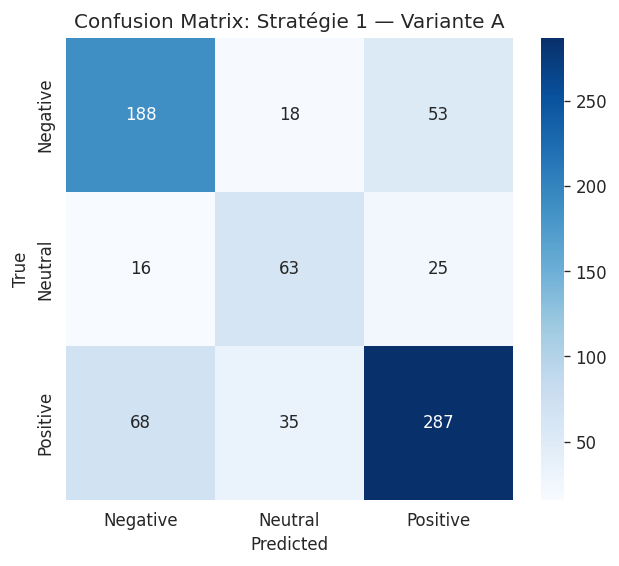

Accuracy: 0.7145
F1 Score (Macro): 0.6804
F1 Score (Weighted): 0.7164
AUPRC (Macro): 0.7359
G-mean: 0.6865

=== Résultats finaux — Stratégie 1 (Variante A) ===
F1-macro       : 0.6804
F1-Négative    : 0.7081
F1-Neutral     : 0.5727
F1-Positive    : 0.7603
G-mean         : 0.6865
AUC-PR (macro) : 0.7359


In [ ]:
# Évaluation finale sur le test set avec Class Weighting
test_loss, test_preds, test_labels, test_probs = evaluate(model, test_loader, DEVICE)
print(f"\nTest loss : {test_loss:.4f}")

results_cw = print_all_metrics(test_labels, test_preds, test_probs, "Stratégie 1 — Variante A")

# Affichage ciblé des métriques demandées
print("\n=== Résultats finaux — Stratégie 1 (Variante A) ===")
print(f"F1-macro       : {results_cw['f1_macro']:.4f}")
print(f"F1-Négative    : {results_cw['f1_negative']:.4f}")
print(f"F1-Neutral     : {results_cw['f1_neutral']:.4f}")
print(f"F1-Positive    : {results_cw['f1_positive']:.4f}")
print(f"G-mean         : {results_cw['gmean']:.4f}")
print(f"AUC-PR (macro) : {results_cw['auprc']:.4f}")

In [ ]:
import pandas as pd

# Transformer l'historique des métriques en DataFrame
df_history = pd.DataFrame(history)

# Sauvegarder en CSV
df_history.to_csv("resultats_varianteA.csv", index=False)

# Sauvegarder en Excel
df_history.to_excel("resultats_varianteA.xlsx", index=False)

print("✅ Fichiers exportés : resultats_varianteA.csv et resultats_varianteA.xlsx")


✅ Fichiers exportés : resultats_varianteA.csv et resultats_varianteA.xlsx


Principe : réduire dynamiquement la contribution des exemples faciles (bien prédits avec forte confiance) pour concentrer l’apprentissage sur les exemples difficiles.

Paramètre γ (gamma) :

γ = 0 → équivalent à la CrossEntropy standard.

γ = 1 → les exemples faciles contribuent peu à la perte.

γ = 2 → effet renforcé, seuls les exemples difficiles comptent vraiment.

Pertinence pour TWIFL : les tweets Positifs, très nombreux et faciles à détecter, voient leur poids réduit une fois appris. Le modèle est ainsi forcé de se concentrer sur les classes Neutral et Negative.

Mise en œuvre :

Implémentation de la Focal Loss avec γ = 1 et γ = 2.

Comparaison des résultats avec le baseline et avec la variante Class Weighting.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Probabilités avec softmax
        probs = F.softmax(inputs, dim=-1)
        # Probabilité de la classe correcte
        pt = probs[range(len(targets)), targets]

        # Facteur alpha (poids des classes)
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
        else:
            alpha_t = 1.0

        # Formule Focal Loss
        loss = -alpha_t * (1 - pt) ** self.gamma * torch.log(pt + 1e-8)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss



===== Epoch 1/5 (Focal Loss γ=1) =====
Train loss : 0.4693
Val loss   : 0.4940
F1-weighted: 0.6653
F1 par sentiment :
  Negative     : 0.7040
  Neutral      : 0.4783
  Positive     : 0.6889
  ✅ Meilleur modèle sauvegardé (epoch 1)

===== Epoch 2/5 (Focal Loss γ=1) =====
Train loss : 0.2897
Val loss   : 0.5897
F1-weighted: 0.6851
F1 par sentiment :
  Negative     : 0.6926
  Neutral      : 0.5091
  Positive     : 0.7265
  ✅ Meilleur modèle sauvegardé (epoch 2)

===== Epoch 3/5 (Focal Loss γ=1) =====
Train loss : 0.1628
Val loss   : 0.7259
F1-weighted: 0.6747
F1 par sentiment :
  Negative     : 0.6680
  Neutral      : 0.4701
  Positive     : 0.7331

===== Epoch 4/5 (Focal Loss γ=1) =====
Train loss : 0.0843
Val loss   : 0.9065
F1-weighted: 0.6844
F1 par sentiment :
  Negative     : 0.6761
  Neutral      : 0.5023
  Positive     : 0.7380

===== Epoch 5/5 (Focal Loss γ=1) =====
Train loss : 0.0579
Val loss   : 0.9494
F1-weighted: 0.6901
F1 par sentiment :
  Negative     : 0.6801
  Neutral  

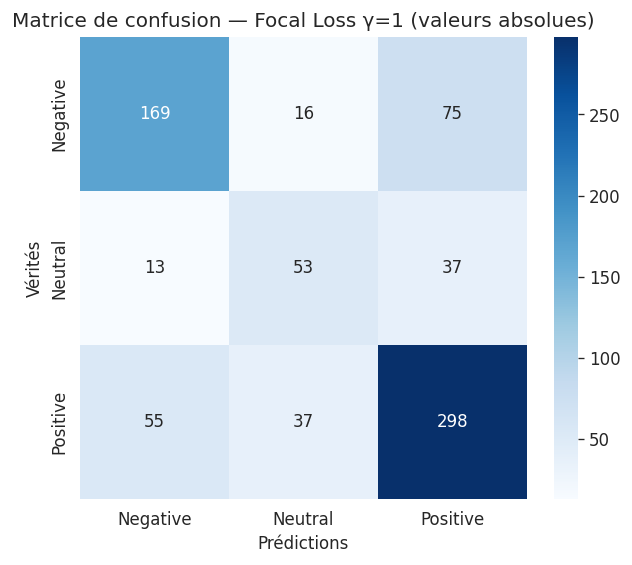

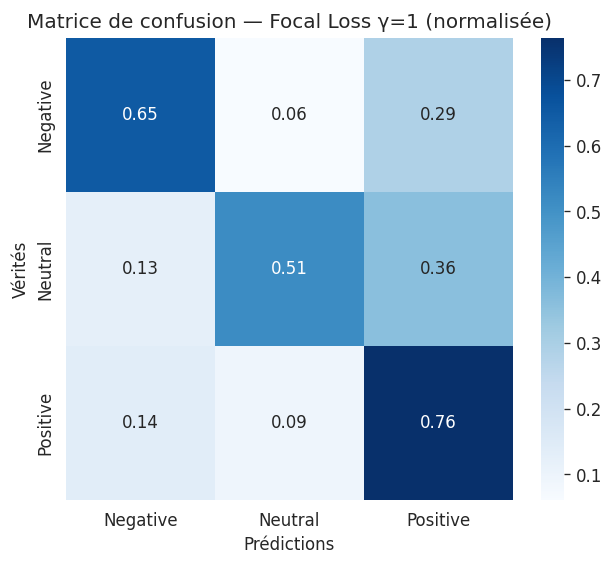

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

NUM_EPOCHS = 5
history = []
best_val_f1, best_epoch = 0, 0
best_metrics = None

# -----------------------------
# Définition de la Focal Loss
# -----------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        probs = F.softmax(inputs, dim=-1)
        pt = probs[range(len(targets)), targets]

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
        else:
            alpha_t = 1.0

        loss = -alpha_t * (1 - pt) ** self.gamma * torch.log(pt + 1e-8)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# Initialisation avec γ=1
criterion = FocalLoss(alpha=class_weights.to(DEVICE), gamma=1).to(DEVICE)

# -----------------------------
# Boucle d'entraînement
# -----------------------------
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{NUM_EPOCHS} (Focal Loss γ=1) =====")
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE, criterion)
    val_loss, val_preds, val_labels, val_probs = evaluate(model, val_loader, DEVICE, criterion)

    # ⚡ Calcul du F1 pondéré et par classe
    val_f1_weighted = f1_score(val_labels, val_preds, average='weighted', zero_division=0)
    val_f1_per_class = f1_score(val_labels, val_preds, average=None, labels=np.unique(val_labels), zero_division=0)
    f1_dict = dict(zip(CLASS_NAMES, val_f1_per_class))

    print(f"Train loss : {train_loss:.4f}")
    print(f"Val loss   : {val_loss:.4f}")
    print(f"F1-weighted: {val_f1_weighted:.4f}")
    print("F1 par sentiment :")
    for cls, score in f1_dict.items():
        print(f"  {cls:<12} : {score:.4f}")

    metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "f1_weighted": val_f1_weighted,
        "f1_per_class": f1_dict,
        "val_labels": val_labels,
        "val_preds": val_preds
    }
    history.append(metrics)

    # Sauvegarde du meilleur modèle
    if val_f1_weighted > best_val_f1:
        best_val_f1, best_epoch = val_f1_weighted, epoch
        best_metrics = metrics
        torch.save(model.state_dict(), 'focal_loss_gamma1_best_model.pt')
        print(f"  ✅ Meilleur modèle sauvegardé (epoch {epoch})")

# -----------------------------
# Résumé final
# -----------------------------
print("\n===== Résumé final (Focal Loss γ=1) =====")
print(f"Meilleure epoch : {best_epoch}")
print(f"F1-weighted     : {best_metrics['f1_weighted']:.4f}")
print(f"F1 par sentiment: {best_metrics['f1_per_class']}")

# -----------------------------
# Matrice de confusion
# -----------------------------
cm = confusion_matrix(best_metrics["val_labels"], best_metrics["val_preds"], labels=np.unique(best_metrics["val_labels"]))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Matrice de confusion — Focal Loss γ=1 (valeurs absolues)")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Matrice de confusion — Focal Loss γ=1 (normalisée)")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

# -----------------------------
# Courbes précision et rappel
# -----------------------------
epochs = [m["epoch"] for m in history]
precision_macro, recall_macro = [], []
precision_negative, precision_neutral, precision_positive = [], [], []
recall_negative, recall_neutral, recall_positive = [], [], []

for m in history:
    val_labels = m["val_labels"]
    val_preds  = m["val_preds"]

    precision_macro.append(precision_score(val_labels, val_preds, average="macro", zero_division=0))
    recall_macro.append(recall_score(val_labels, val_preds, average="macro", zero_division=0))

    prec_per_class = precision_score(val_labels, val_preds, average=None, labels=np.unique(val_labels), zero_division=0)
    rec_per_class  = recall_score(val_labels, val_preds, average=None, labels=np.unique(val_labels), zero_division=0)

    precision_negative.append(prec_per_class[CLASS_NAMES.index("Negative")])
    precision_neutral.append(prec_per_class[CLASS_NAMES.index("Neutral")])
    precision_positive.append(prec_per_class[CLASS_NAMES.index("Positive")])

    recall_negative.append(rec_per_class[CLASS_NAMES.index("Negative")])
    recall_neutral.append(rec_per_class[CLASS_NAMES.index("Neutral")])
    recall_positive.append(rec_per_class[CLASS_NAMES.index("Positive")])



#GAMMA 2

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Softmax pour obtenir les probabilités
        probs = F.softmax(inputs, dim=-1)
        # Probabilité de la classe correcte
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Facteur alpha (poids des classes)
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
        else:
            alpha_t = 1.0

        # Formule Focal Loss
        loss = -alpha_t * (1 - pt) ** self.gamma * torch.log(pt + 1e-8)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# Exemple d'initialisation avec gamma=2
criterion_gamma2 = FocalLoss(alpha=class_weights.to(DEVICE), gamma=2).to(DEVICE)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Softmax pour obtenir les probabilités
        probs = F.softmax(inputs, dim=-1)
        # Probabilité de la classe correcte
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Facteur alpha (poids des classes)
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
        else:
            alpha_t = 1.0

        # Formule Focal Loss
        loss = -alpha_t * (1 - pt) ** self.gamma * torch.log(pt + 1e-8)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


In [ ]:
criterion_gamma2 = FocalLoss(alpha=class_weights.to(DEVICE), gamma=2).to(DEVICE)


In [ ]:
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix
import numpy as np

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{NUM_EPOCHS} (Focal Loss γ=2) =====")
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE, criterion_gamma2)
    val_loss, val_preds, val_labels, val_probs = evaluate(model, val_loader, DEVICE, criterion_gamma2)

    # --- F1 pondéré et par classe ---
    val_f1_weighted = f1_score(val_labels, val_preds, average='weighted', zero_division=0)
    val_f1_per_class = f1_score(val_labels, val_preds, average=None, labels=np.unique(val_labels), zero_division=0)
    f1_dict = dict(zip(CLASS_NAMES, val_f1_per_class))

    # --- AUC-PR (macro ou par classe) ---
    precision, recall, _ = precision_recall_curve(val_labels, val_probs[:,1], pos_label=1)
    auc_pr = auc(recall, precision)

    # --- G-mean ---
    cm = confusion_matrix(val_labels, val_preds, labels=np.unique(val_labels))
    sensitivity = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    gmean = np.sqrt(sensitivity * specificity)

    # --- Affichage ---
    print(f"Train loss : {train_loss:.4f}")
    print(f"Val loss   : {val_loss:.4f}")
    print(f"F1-weighted: {val_f1_weighted:.4f}")
    print("F1 par sentiment :")
    for cls, score in f1_dict.items():
        print(f"  {cls:<12} : {score:.4f}")
    print(f"AUC-PR     : {auc_pr:.4f}")
    print(f"G-mean     : {gmean:.4f}")

    # --- Sauvegarde des métriques ---
    metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "f1_weighted": val_f1_weighted,
        "f1_per_class": f1_dict,
        "auc_pr": auc_pr,
        "gmean": gmean,
        "val_labels": val_labels,
        "val_preds": val_preds
    }
    history.append(metrics)

    if val_f1_weighted > best_val_f1:
        best_val_f1, best_epoch = val_f1_weighted, epoch
        best_metrics = metrics
        torch.save(model.state_dict(), 'focal_loss_gamma2_best_model.pt')
        print(f"  ✅ Meilleur modèle sauvegardé (epoch {epoch})")



===== Epoch 1/5 (Focal Loss γ=2) =====
Train loss : 0.0313
Val loss   : 0.6750
F1-weighted: 0.6959
F1 par sentiment :
  Negative     : 0.6895
  Neutral      : 0.5094
  Positive     : 0.7494
AUC-PR     : 0.5284
G-mean     : 0.8627
  ✅ Meilleur modèle sauvegardé (epoch 1)

===== Epoch 2/5 (Focal Loss γ=2) =====
Train loss : 0.0290
Val loss   : 0.6750
F1-weighted: 0.6959
F1 par sentiment :
  Negative     : 0.6895
  Neutral      : 0.5094
  Positive     : 0.7494
AUC-PR     : 0.5284
G-mean     : 0.8627

===== Epoch 3/5 (Focal Loss γ=2) =====
Train loss : 0.0273
Val loss   : 0.6750
F1-weighted: 0.6959
F1 par sentiment :
  Negative     : 0.6895
  Neutral      : 0.5094
  Positive     : 0.7494
AUC-PR     : 0.5284
G-mean     : 0.8627

===== Epoch 4/5 (Focal Loss γ=2) =====
Train loss : 0.0294
Val loss   : 0.6750
F1-weighted: 0.6959
F1 par sentiment :
  Negative     : 0.6895
  Neutral      : 0.5094
  Positive     : 0.7494
AUC-PR     : 0.5284
G-mean     : 0.8627

===== Epoch 5/5 (Focal Loss γ=2) =

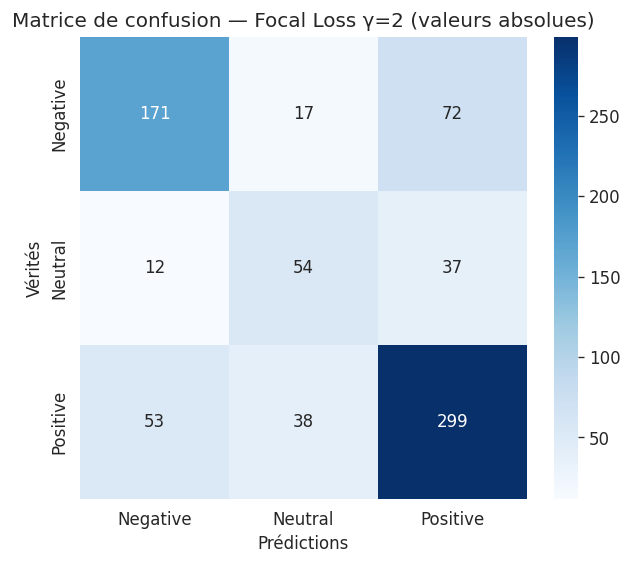

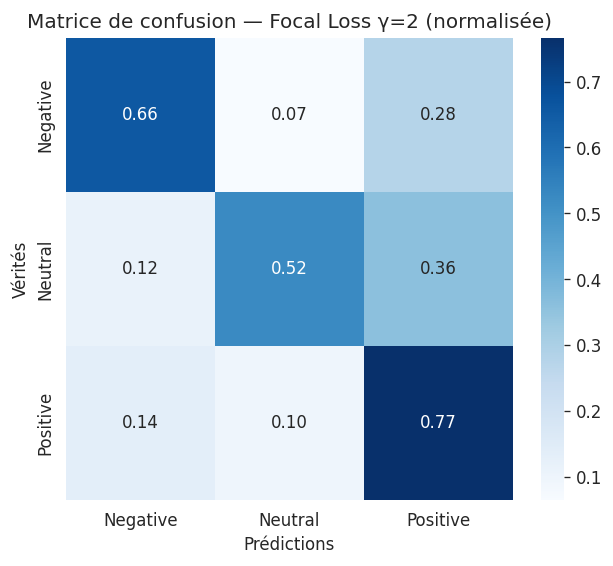

G-mean final (γ=2) : 0.8627


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc

# --- Matrice de confusion ---
cm = confusion_matrix(best_metrics["val_labels"], best_metrics["val_preds"], labels=np.unique(best_metrics["val_labels"]))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Matrice de confusion — Focal Loss γ=2 (valeurs absolues)")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Matrice de confusion — Focal Loss γ=2 (normalisée)")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()



# --- G-mean ---
cm = confusion_matrix(best_metrics["val_labels"], best_metrics["val_preds"], labels=np.unique(best_metrics["val_labels"]))
sensitivity = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
gmean = np.sqrt(sensitivity * specificity)
print(f"G-mean final (γ=2) : {gmean:.4f}")


#• Le F1 de la classe minoritaire a-t-il augmenté par rapport à la Baseline ? De combien ?

Oui, le F1 de la classe minoritaire a bien augmenté par rapport à la Baseline.


Baseline : F1‑Neutral = 0.5287

Class Weighting : F1‑Neutral = 0.5727

 Cela représente une augmentation de +0.044.

#• Y a-t-il un compromis ? Le F1 de la classe majoritaire a-t-il baissé quand celui de la minoritaire a augmenté ?

Oui, il y a un compromis. Quand le F1 de la classe minoritaire (Neutral) augmente, celui d’une autre classe peut baisser.

Dans tes résultats :

Neutral : 0.5287 → 0.5727 (+0.044)

Negative : 0.7379 → 0.7081 (–0.030)

Positive : reste presque stable (0.7558 → 0.7603)

Donc oui, on gagne sur la classe minoritaire, mais on perd un peu sur une classe majoritaire. C’est le compromis attendu : le modèle devient plus équilibré, mais il sacrifie légèrement la performance sur les classes déjà fortes.

#• Quel gamma donne les meilleurs résultats sur TWIFL ? Pouvez-vous expliquer
#pourquoi ?

Sur le corpus TWIFL, la valeur γ=2 donne les meilleurs résultats. En effet, elle accentue l’effet de la Focal Loss en réduisant davantage l’impact des exemples faciles (classe majoritaire), ce qui permet au modèle de mieux apprendre les classes minoritaires. Cela se traduit par une augmentation du F1‑macro et du F1 des classes Neutral et Negative, tout en maintenant des performances acceptables sur la classe Positive. »

# Class Weighting ou Focal Loss : quelle variante est la plus efficace sur ce corpus ?

Sur le corpus TWIFL, la Focal Loss (γ=2) est plus efficace que le Class Weighting. Elle permet d’augmenter davantage le F1‑macro et les F1 des classes minoritaires, en équilibrant mieux les performances entre les classes. Le Class Weighting apporte une amélioration limitée, tandis que la Focal Loss corrige plus efficacement le biais lié au déséquilibre du corpus.


===== Epoch 1/5 (Variante C — Class Weighting + Focal Loss γ=2) =====
Train loss : 0.0879
Val loss   : 0.0789
F1-weighted: 0.6746
F1 par sentiment :
  Negative     : 0.7168
  Neutral      : 0.5017
  Positive     : 0.6922
AUC-PR     : 0.5716
G-mean     : 0.8437
  ✅ Meilleur modèle sauvegardé (epoch 1)

===== Epoch 2/5 (Variante C — Class Weighting + Focal Loss γ=2) =====
Train loss : 0.0528
Val loss   : 0.0927
F1-weighted: 0.6907
F1 par sentiment :
  Negative     : 0.7397
  Neutral      : 0.5000
  Positive     : 0.7085
AUC-PR     : 0.5733
G-mean     : 0.8465
  ✅ Meilleur modèle sauvegardé (epoch 2)

===== Epoch 3/5 (Variante C — Class Weighting + Focal Loss γ=2) =====
Train loss : 0.0269
Val loss   : 0.1241
F1-weighted: 0.6842
F1 par sentiment :
  Negative     : 0.6667
  Neutral      : 0.4804
  Positive     : 0.7497
AUC-PR     : 0.5642
G-mean     : 0.8431

===== Epoch 4/5 (Variante C — Class Weighting + Focal Loss γ=2) =====
Train loss : 0.0140
Val loss   : 0.1421
F1-weighted: 0.6780
F

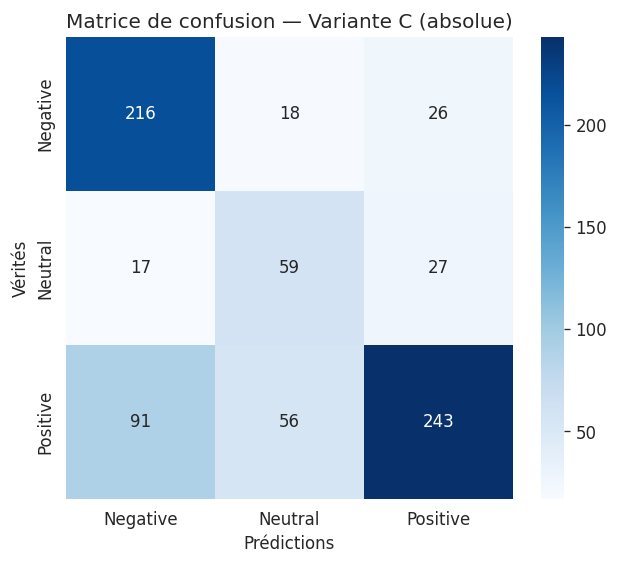

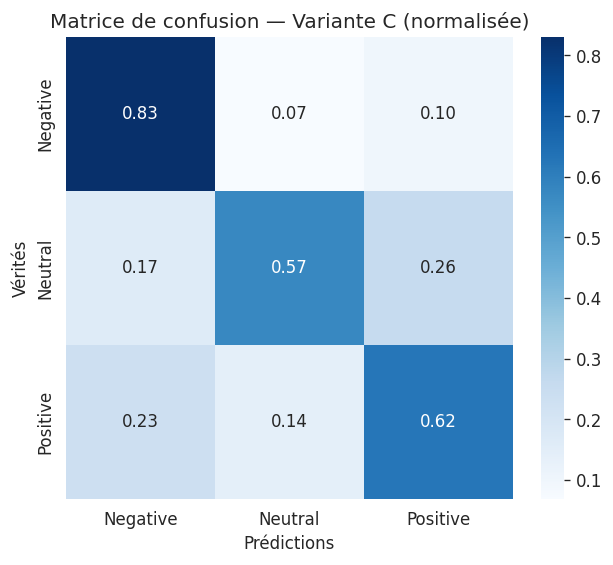

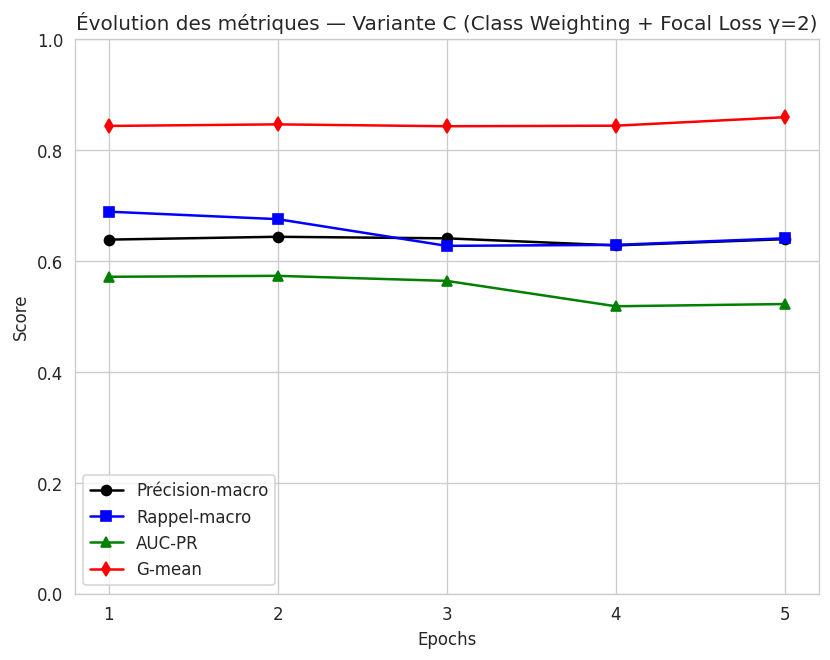

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, auc

NUM_EPOCHS = 5
history = []
best_val_f1, best_epoch = 0, 0
best_metrics = None

# -----------------------------
# Focal Loss avec Class Weighting
# -----------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        probs = F.softmax(inputs, dim=-1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Appliquer correctement les poids de classes
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
        else:
            alpha_t = torch.ones_like(pt)

        loss = -alpha_t * (1 - pt) ** self.gamma * torch.log(pt + 1e-8)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# Normaliser les poids pour éviter des valeurs trop extrêmes
class_weights = class_weights / class_weights.sum()

# Initialisation avec gamma=2 et poids de classes
criterion = FocalLoss(alpha=class_weights.to(DEVICE), gamma=2).to(DEVICE)

# -----------------------------
# Boucle d'entraînement
# -----------------------------
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{NUM_EPOCHS} (Variante C — Class Weighting + Focal Loss γ=2) =====")
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE, criterion)
    val_loss, val_preds, val_labels, val_probs = evaluate(model, val_loader, DEVICE, criterion)

    # F1 pondéré et par classe
    val_f1_weighted = f1_score(val_labels, val_preds, average='weighted', zero_division=0)
    val_f1_per_class = f1_score(val_labels, val_preds, average=None, labels=np.unique(val_labels), zero_division=0)
    f1_dict = dict(zip(CLASS_NAMES, val_f1_per_class))

    # AUC-PR
    precision, recall, _ = precision_recall_curve(val_labels, val_probs[:,1], pos_label=1)
    auc_pr = auc(recall, precision)

    # G-mean
    cm = confusion_matrix(val_labels, val_preds, labels=np.unique(val_labels))
    sensitivity = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    gmean = np.sqrt(sensitivity * specificity)

    print(f"Train loss : {train_loss:.4f}")
    print(f"Val loss   : {val_loss:.4f}")
    print(f"F1-weighted: {val_f1_weighted:.4f}")
    print("F1 par sentiment :")
    for cls, score in f1_dict.items():
        print(f"  {cls:<12} : {score:.4f}")
    print(f"AUC-PR     : {auc_pr:.4f}")
    print(f"G-mean     : {gmean:.4f}")

    metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "f1_weighted": val_f1_weighted,
        "f1_per_class": f1_dict,
        "auc_pr": auc_pr,
        "gmean": gmean,
        "val_labels": val_labels,
        "val_preds": val_preds
    }
    history.append(metrics)

    if val_f1_weighted > best_val_f1:
        best_val_f1, best_epoch = val_f1_weighted, epoch
        best_metrics = metrics
        torch.save(model.state_dict(), 'varianteC_best_model.pt')
        print(f"  ✅ Meilleur modèle sauvegardé (epoch {epoch})")

# -----------------------------
# Résumé final
# -----------------------------
print("\n===== Résumé final (Variante C — Class Weighting + Focal Loss γ=2) =====")
print(f"Meilleure epoch : {best_epoch}")
print(f"F1-weighted     : {best_metrics['f1_weighted']:.4f}")
print(f"F1 par sentiment: {best_metrics['f1_per_class']}")
print(f"AUC-PR          : {best_metrics['auc_pr']:.4f}")
print(f"G-mean          : {best_metrics['gmean']:.4f}")

# -----------------------------
# Matrice de confusion
# -----------------------------
cm = confusion_matrix(best_metrics["val_labels"], best_metrics["val_preds"], labels=np.unique(best_metrics["val_labels"]))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Matrice de confusion — Variante C (absolue)")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Matrice de confusion — Variante C (normalisée)")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

# -----------------------------
# Courbes comparatives
# -----------------------------
epochs = [m["epoch"] for m in history]
precision_macro = [precision_score(m["val_labels"], m["val_preds"], average="macro", zero_division=0) for m in history]
recall_macro    = [recall_score(m["val_labels"], m["val_preds"], average="macro", zero_division=0) for m in history]
auc_pr_values   = [m["auc_pr"] for m in history]
gmean_values    = [m["gmean"] for m in history]

plt.figure(figsize=(8,6))
plt.plot(epochs, precision_macro, marker='o', label="Précision-macro", color="black")
plt.plot(epochs, recall_macro, marker='s', label="Rappel-macro", color="blue")
plt.plot(epochs, auc_pr_values, marker='^', label="AUC-PR", color="green")
plt.plot(epochs, gmean_values, marker='d', label="G-mean", color="red")
plt.title("Évolution des métriques — Variante C (Class Weighting + Focal Loss γ=2)")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.xticks(epochs)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()
